In [ ]:
from dataclasses import dataclass
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.animation import FuncAnimation
num_bits = 4
num_states = 2 ** num_bits

In [ ]:
# Define possible cost functions
def cost_quadratic(x):
    return (x - 3)**2 + 1

def cost_linear(x):
    return x

# IMPORTANT NOTE:
# I made a mistkae. I thought that QAOA was meant to minimise a cost function
# I'm wrong - it's made to maximise.
# Therefore, I've changed each of the cost functions to be maximisation functions


# Produces the cost based on the application to max-cut
# E is the set of edges, provided as a list of duples of vertices (0-indexed)
# The ith least significant bit of x = the group the ith vertex belongs to
# this is the regular old max cut cost function
def cost_max_cut(E, x: int):
  cost = 0
  for v1, v2 in E:
    # group1 is 1 iff the v1-th bit is 1
    group1 = ((x >> v1) & 1)
    group2 = ((x >> v2) & 1)
    if (group1 != group2): cost += 1
  return cost

# Produces the cost based on an application to the partition problem
# nums is a list (or tuple) of the available numbers to partition
# The cost is equal to the min of each group's sum
# The bit string tells us which numbers are in the partition,
# and is ordered from LSB to MSB

def cost_partition(nums, x):
  sum_zeroes = 0
  sum_ones = 0
  for i, num in enumerate(nums):
    group = ((x >> i) & 1)
    if (group == 1): sum_ones += num
    else: sum_zeroes += num

  return min(sum_ones, sum_zeroes)

# Produces the cost based on an application of vertex cover
# We allow not all edges to be covered, but apply a penalty to uncovered edges
# E is the set of edges, provided as a list of duples of vertices (0-indexed)
# Cost is defined as num(vertices not chosen) + edge_cost * num(edges covered)
def cost_vertex_cover(E, x, edge_cost):
  max_vertex = max([i for (i,j) in E] + [j for (i,j) in E])
  num_vertices = max_vertex + 1
  vertices_chosen = [i for i in range(max_vertex + 1) if (x >> i) & 1]
  num_edges_covered = 0
  for edge in E:
    if edge[0] in vertices_chosen or edge[1] in vertices_chosen:
      num_edges_covered += 1
  return num_vertices - len(vertices_chosen) + edge_cost * num_edges_covered



In [ ]:
# Utilise flexible cost function
E = [(0, 1), (0, 2), (0, 3), (2, 3)]
integer_valued_cost_function = lambda x: cost_partition([1, 2, 4, 8], x)

In [ ]:
# Create class for storing state vector of qubit strings
@dataclass
class BitState:
  index: int
  bitstring: str
  cost: float
  real_component: float
  imag_component: float
  @property
  def probability(self) -> float:
      return self.real_component**2 + self.imag_component**2 # = real_component^2 + imag_component^2)
  @property
  def complex_amp(self) -> complex:
      return complex(self.real_component, self.imag_component)

  @property
  def argument_degrees(self) -> float:
      return np.angle(self.complex_amp, deg = True)

  @property
  def argument(self) -> float:
      return np.angle(self.complex_amp)

initial_amplitude = 1/np.sqrt(num_states)
states = []

# Initialise all the bitstring states to equal amplitudes and initialise relevant information
for i in range(num_states):
  cost_value = integer_valued_cost_function(i)        # compute the corresponding cost of the bit via defined function

  states.append(BitState(
      index = i,
      bitstring = np.binary_repr(i, width=num_bits),  # Store the bitstring representation (converting i to binary)
      cost = cost_value,                              # Store computed cost
      real_component=initial_amplitude,               # Initialise to only real axis
      imag_component=0))                              # Initialise imaginary axis to 0


# Create pandas dataframe for storing all information
df = pd.DataFrame([
    {
        "index": s.index,
        "bitstring": s.bitstring,
        "cost": s.cost,
        "Real": s.real_component,
        "Imaginary": s.imag_component,
        "Argument": s.argument_degrees,
        "Probability": s.probability,
    }
    for s in states
]).sort_values("index")

# print table
print(df.to_string(index=False))


# Plot the argand diagram for a given state.
def plot_state_vector(state):

    re = float(state.real_component)
    im = float(state.imag_component)

    plt.figure(figsize=(4, 4))
    # Arrow from origin to (Re, Im)
    plt.quiver(0.0, 0.0, re, im, angles="xy", scale_units="xy", scale=1)

    # Axes and cosmetics
    plt.axhline(0, lw=1); plt.axvline(0, lw=1)
    lim = max(1.1 * max(abs(re), abs(im), 1e-12), 0.5)
    plt.xlim(-lim, lim); plt.ylim(-lim, lim)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("Real axis"); plt.ylabel("Imaginary axis")
    plt.title(f"(index: {state.index}) (bitstring: {state.bitstring}) (cost={state.cost:.3f})")
    plt.tight_layout()
    plt.show()

 index bitstring  cost  Real  Imaginary  Argument  Probability
     0      0000     0  0.25          0       0.0       0.0625
     1      0001     1  0.25          0       0.0       0.0625
     2      0010     2  0.25          0       0.0       0.0625
     3      0011     3  0.25          0       0.0       0.0625
     4      0100     4  0.25          0       0.0       0.0625
     5      0101     5  0.25          0       0.0       0.0625
     6      0110     6  0.25          0       0.0       0.0625
     7      0111     7  0.25          0       0.0       0.0625
     8      1000     7  0.25          0       0.0       0.0625
     9      1001     6  0.25          0       0.0       0.0625
    10      1010     5  0.25          0       0.0       0.0625
    11      1011     4  0.25          0       0.0       0.0625
    12      1100     3  0.25          0       0.0       0.0625
    13      1101     2  0.25          0       0.0       0.0625
    14      1110     1  0.25          0       0.0      

In [ ]:
def apply_phase_separator(states, gamma):
  for state in states:
    rotation = np.exp(-1j * gamma * state.cost)
    new_value = state.complex_amp * rotation
    state.real_component = new_value.real
    state.imag_component = new_value.imag

In [ ]:
from scipy.linalg import expm

pauli_x = np.array([[0, 1],
                    [1, 0]])


def calculate_paulis(num_bits):
  paulis = []
  for i in range(num_bits):
    pauli = np.identity(1)
    for j in range(num_bits):
      if (i != j):
        pauli = np.kron(pauli, np.identity(2))
      else:
        pauli = np.kron(pauli, pauli_x)

    paulis.append(pauli)

  return paulis


pauli = sum(calculate_paulis(2))
pauli_exp = expm(-1j * math.pi / 16 * pauli)
pauli_exp = np.round(pauli_exp, 2)
print(pauli)
print(pauli_exp)


def apply_mixing_operator(states: list[BitState], pauli, beta):
  pauli_exp = expm(-1j * beta * pauli)
  # for i in pauli_exps:
    # print(i.round(1), "\n")
  state_values = np.array([state.complex_amp for state in states])
  basis_vectors = np.identity(len(states))

  result = np.matrix([0. + 0.j for i in states])
  result_parts = [[] for i in states]
  # print(pauli_exp.round(1))
  for id, basis_vector in enumerate(basis_vectors):
    projection = [state_values[i] * basis_vector[i] for i in range(len(basis_vector))]
    after_pauli = pauli_exp.dot(projection)
    result += after_pauli
    result_parts[id].append((id, pauli_exp[id][id]))
    coids = [i for i in range(len(projection)) if pauli_exp[i][id] != 0 and i != id]
    for coid in coids:
      result_parts[coid].append((id, pauli_exp[coid][id]))

  for i, basis_vector in enumerate(basis_vectors):
    component = np.dot(result, basis_vector).item()
    states[i].real_component = component.real
    states[i].imag_component = component.imag

  return (states, result_parts)


[[0. 1. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]]
[[ 0.96+0.j    0.  -0.19j  0.  -0.19j -0.04+0.j  ]
 [ 0.  -0.19j  0.96+0.j   -0.04+0.j    0.  -0.19j]
 [ 0.  -0.19j -0.04+0.j    0.96+0.j    0.  -0.19j]
 [-0.04+0.j    0.  -0.19j  0.  -0.19j  0.96+0.j  ]]


In [ ]:
def plot_result_parts(states, parts, dest, new_states):
    plt.figure(figsize=(5, 5))
    re = float(states[dest].real_component)
    im = float(states[dest].imag_component)
    plt.quiver(0.0, 0.0, re, im, angles = "xy", scale_units = "xy", scale = 1, color = 'r')

    sum = 0. + 0.j
    for i, part in enumerate(parts[dest]):
      src, multiplier = part
      if (src != dest):
        re = float(states[src].real_component)
        im = float(states[src].imag_component)
        plt.quiver(0.0, 0.0, re, im, angles="xy", scale_units="xy", scale=1, color = (0.7, 0.7, 0.7, 0.6))

      number = states[src].complex_amp * multiplier
      sum += number
      re = float(number.real)
      im = float(number.imag)
      color = color = (0.35, 0.35, 0.35)
      if (src == dest):
        color = (1, 0.5, 0)
      plt.quiver(0.0, 0.0, re, im, angles="xy", scale_units="xy", scale=1, color = color)

    assert(sum == new_states[dest].complex_amp)
    re = float(sum.real)
    im = float(sum.imag)
    plt.quiver(0.0, 0.0, re, im, angles="xy", scale_units="xy", scale=1, color = (0, 1, 0))

    # Axes and cosmetics
    plt.axhline(0, lw=1); plt.axvline(0, lw=1)
    lim = max(1.1 * max(abs(re), abs(im), 1e-12), 0.5)
    plt.xlim(-lim, lim); plt.ylim(-lim, lim)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("Real axis"); plt.ylabel("Imaginary axis")
    plt.title(f"(index: {states[dest].index}) (bitstring: {states[dest].bitstring}))")
    plt.tight_layout()
    plt.show()

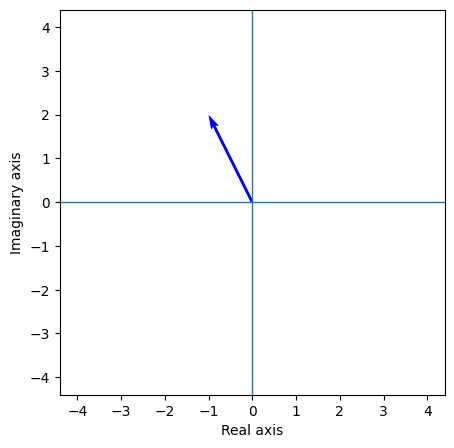

In [ ]:

# Rotation function
def rotate(vec, angle):
  rot = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
  return rot @ vec

# Interpolation function
def interpolate(src, dest, t):
  theta = -np.angle(dest) + np.angle(src)
  if (theta < 0): theta += 2 * math.pi
  if (theta >= 2 * math.pi): theta -= 2 * math.pi
  angle = t * theta
  scale_ratio = abs(dest) / abs(src)
  scale = scale_ratio ** t
  res = scale * src * expm(-1j * angle)
  return np.array([res.real, res.imag])

v0 = 4 + 2j
v1 = -1 + 2j

fig = plt.figure(figsize = (5, 5))
plt.axhline(0, lw=1); plt.axvline(0, lw=1)
lim = max(1.1 * max(4, 4, 1e-12), 0.5)
plt.xlim(-lim, lim); plt.ylim(-lim, lim)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Real axis"); plt.ylabel("Imaginary axis")

arrow = plt.quiver(0, 0, v0.real, v0.imag, angles='xy', scale_units='xy', scale=1, color='blue')

def update(frame):
  t = min(1, frame / 50)
  vec = interpolate(v0, v1, t)
  arrow.set_UVC(vec[0], vec[1])
  return arrow,

from IPython.display import HTML

ani = FuncAnimation(fig, update, frames=100, interval=10, blit=True)
HTML(ani.to_jshtml())

In [ ]:
def animate(states, parts, dest, new_states):
  fig = plt.figure(figsize = (5, 5))
  plt.axhline(0, lw=1); plt.axvline(0, lw=1)
  lim = 0.5
  plt.xlim(-lim, lim); plt.ylim(-lim, lim)
  plt.gca().set_aspect("equal", adjustable="box")
  plt.xlabel("Real axis"); plt.ylabel("Imaginary axis")
  plt.title(f"(index: {states[dest].index}) (bitstring: {states[dest].bitstring}))")

  if dest != 0 and 0 not in [src for src, _ in parts[dest]]:
    fig.patch.set_facecolor((0.8, 0.8, 0.8))
    ax = plt.gca()
    ax.set_facecolor((0.8, 0.8, 0.8))

  re = float(states[dest].real_component)
  im = float(states[dest].imag_component)
  dest_arrow = plt.quiver(0.0, 0.0, re, im, angles = "xy", scale_units = "xy", scale = 1, color = 'r')

  influence_arrows = []
  for i, part in enumerate(parts[dest]):
    src, multiplier = part
    if (src != dest):
      re = float(states[src].real_component)
      im = float(states[src].imag_component)
      arrow = plt.quiver(0.0, 0.0, re, im, angles="xy", scale_units="xy", scale=1, color = (0.4, 0.4, 0.4, 0))
      influence_arrows.append(arrow)

  phase = [0]
  frame_counter = [0, 0, 0, 0, 0, 0]

  def update_stage(frame):
    if frame % 25 == 24:
      phase[0] += 1
    p = min(phase[0], 5)

    if p == 1:
      for arrow in influence_arrows:
        arrow.set_color((0.4, 0.4, 0.4, 0.6))
    if p == 2:
      scale_arrows(frame_counter[2])
    if p == 3:
      rotate_arrows(frame_counter[3])
    if p == 4:
      stack_arrows(frame_counter[4])
    if p == 5 and frame_counter[5] == 0:
      draw_sum()


    frame_counter[p] += 1

    return tuple([dest_arrow] + influence_arrows)

  def scale_arrows(frame_counter):
    t = min(1, frame_counter / 20)
    index = 0
    for i, part in enumerate(parts[dest]):
      src, multiplier = part
      re = float(states[src].real_component)
      im = float(states[src].imag_component)
      v0 = re + im * 1j
      v1 = v0 * abs(multiplier)
      vec = interpolate(v0, v1, t)

      if (src == dest):
        dest_arrow.set_UVC(vec[0], vec[1])
      else:
        influence_arrows[index].set_UVC(vec[0], vec[1])
        index += 1

  def rotate_arrows(frame_counter):
    t = min(1, frame_counter / 20)
    index = 0
    for i, part in enumerate(parts[dest]):
      src, multiplier = part
      re = float(states[src].real_component)
      im = float(states[src].imag_component)
      v0 = (re + im * 1j) * abs(multiplier)
      v1 = (re + im * 1j) * multiplier
      vec = interpolate(v0, v1, t)

      if (src == dest):
        dest_arrow.set_UVC(vec[0], vec[1])
      else:
        influence_arrows[index].set_UVC(vec[0], vec[1])
        index += 1

  def stack_arrows(frame_counter):
    offsets = [dest_arrow.U[0], dest_arrow.V[0]]
    index = 0

    for i in range(frame_counter):
      if (index >= len(influence_arrows)): break
      src, multiplier = parts[dest][i]
      if (src == dest):
        continue
      vec = src * multiplier
      arrow = influence_arrows[index]
      arrow.set_offsets([offsets])
      offsets[0] += arrow.U[0]
      offsets[1] += arrow.V[0]
      index += 1

  def draw_sum():
    tail_u = influence_arrows[-1].get_offsets()[0][0] + influence_arrows[-1].U
    tail_v = influence_arrows[-1].get_offsets()[0][1] + influence_arrows[-1].V
    arrow = plt.quiver(0.0, 0.0, tail_u, tail_v, angles="xy", scale_units="xy", scale=1, color = "green")
    influence_arrows.append(arrow)

  ani = FuncAnimation(fig, update_stage, frames=150, interval=80, blit=True)
  return ani





,index,bitstring,cost,Real,Imaginary,Probability
0,0,0000,0,0.077165,0.115485,0.019291
15,15,1111,0,0.077165,0.115485,0.019291
14,14,1110,1,0.027097,0.040553,0.002379
1,1,0001,1,0.027097,0.040553,0.002379
2,2,0010,2,-0.027097,-0.040553,0.002379
13,13,1101,2,-0.027097,-0.040553,0.002379
12,12,1100,3,-0.077165,-0.115485,0.019291
3,3,0011,3,-0.077165,-0.115485,0.019291
11,11,1011,4,-0.203873,-0.113776,0.054509
4,4,0100,4,-0.203873,-0.113776,0.054509


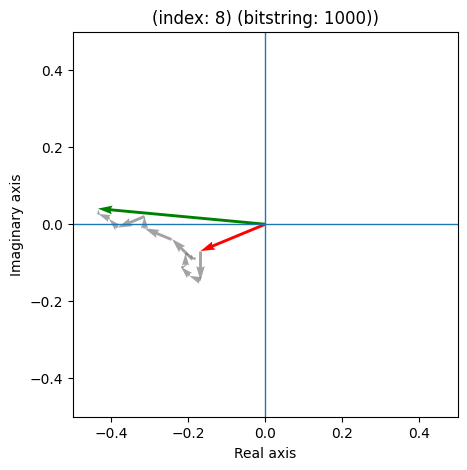

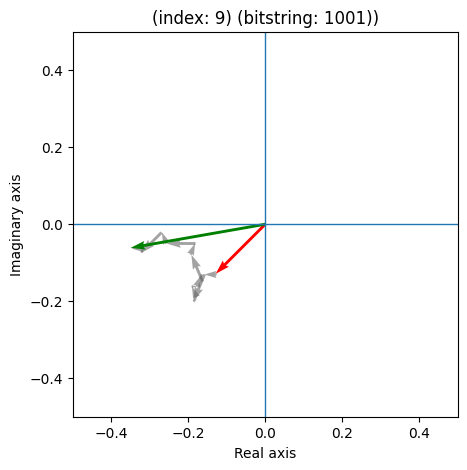

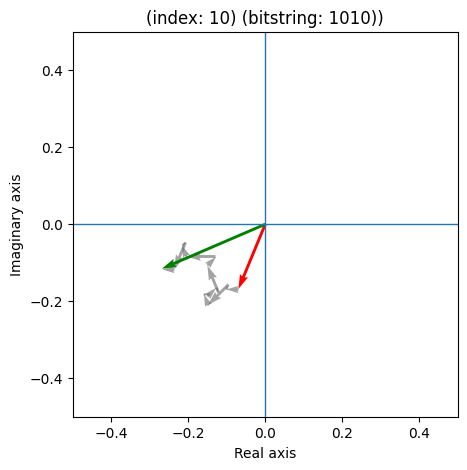

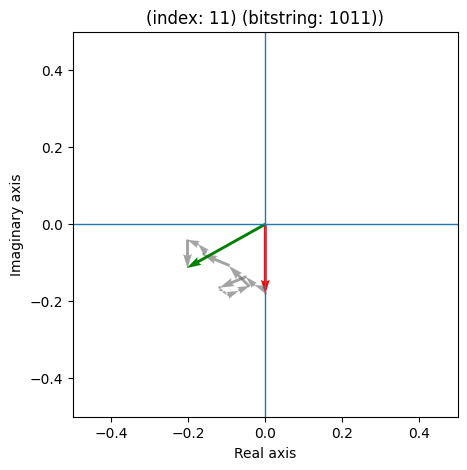

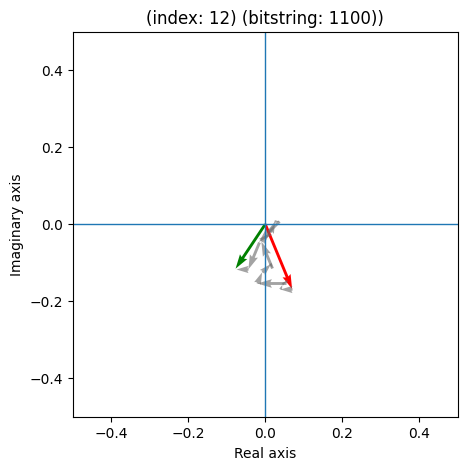

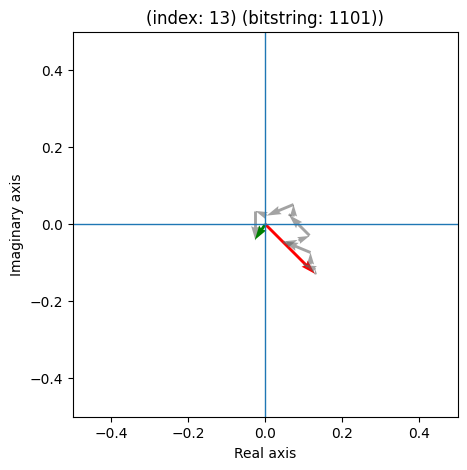

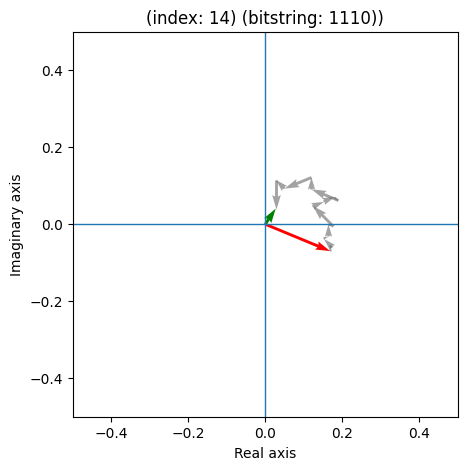

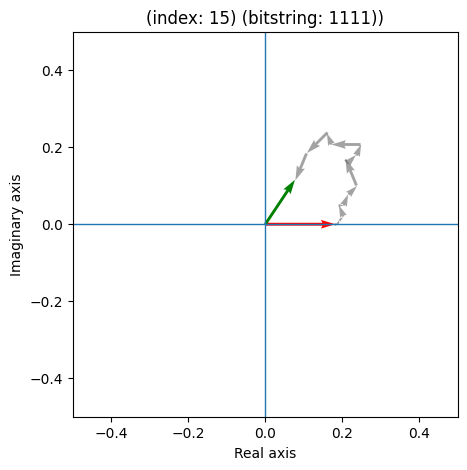

In [ ]:
def show(gamma, beta):
  states = []

  # Initialise all the bitstring states to equal amplitudes and initialise relevant information
  for i in range(num_states):
    cost_value = integer_valued_cost_function(i)        # compute the corresponding cost of the bit via defined function

    states.append(BitState(
        index = i,
        bitstring = np.binary_repr(i, width=num_bits),  # Store the bitstring representation (converting i to binary)
        cost = cost_value,                              # Store computed cost
        real_component=initial_amplitude,               # Initialise to only real axis
        imag_component=0))                              # Initialise imaginary axis to 0


  paulis = calculate_paulis(len(states[0].bitstring))
  pauli_sum = [sum(paulis)]
  apply_phase_separator(states, gamma)
  # for state in states:
      # plot_state_vector(state)
  for i, pauli in enumerate(pauli_sum):
    # print(f"PAULI ON BIT {i} (from MSB)")
    states_copy = [BitState(
        index = state.index,
        bitstring = state.bitstring,
        cost = state.cost,
        real_component = state.real_component,
        imag_component = state.imag_component
    ) for state in states]

    states, result_parts = apply_mixing_operator(states, pauli, beta)
    for j in range(8, len(states_copy)):
      ani = animate(states_copy, result_parts, j, states)
      ani.save(f"ani/sum_{j}.mp4", writer = "ffmpeg")
      # display(plot_result_parts(states_copy, result_parts, i, states))

  return (states)

states = show(math.pi / 8, math.pi / 8)

df = pd.DataFrame([
      {
          "index": s.index,
          "bitstring": s.bitstring,
          "cost": s.cost,
          "Real": s.real_component,
          "Imaginary": s.imag_component,
          "Probability": s.probability,
      }
      for s in states
  ]).sort_values("cost")

display(df)

In [ ]:
def expected_cost(states):
  return sum([s.probability * s.cost for s in states])

def expected_accuracy(states):
  return expected_cost(states) / min([s.cost for s in states])

def average_cost(states):
  return sum([s.cost for s in states]) / len(states)

(average_cost(states), expected_cost(states))

In [ ]:
math.sin(math.pi/8)

In [ ]:
from moviepy.editor import VideoFileClip, clips_array, concatenate_videoclips

# Load your 16 animations for group 1
clips_group = []
for i in range(4):
  clips_group.append([VideoFileClip(f"ani/pauli_{i}_{j}.mp4") for j in range(16)])

# Arrange in 4x4 grid
grids = []
for i,group in enumerate(clips_group):
  grids.append(clips_array([
    clips_group[i][0:4],
    clips_group[i][4:8],
    clips_group[i][8:12],
    clips_group[i][12:16]
]))

# Concatenate groups sequentially
final_video = concatenate_videoclips([grid for grid in grids])

# Export final video
final_video.write_videofile("final_output.mp4")


Moviepy - Building video final_output.mp4.
Moviepy - Writing video final_output.mp4



Moviepy - Done !
Moviepy - video ready final_output.mp4


In [ ]:
!zip -r ani.zip ani

  adding: ani/ (stored 0%)
  adding: ani/pauli_1_12.mp4 (deflated 26%)
  adding: ani/pauli_3_8.mp4 (deflated 22%)
  adding: ani/pauli_3_11.mp4 (deflated 24%)
  adding: ani/pauli_2_12.mp4 (deflated 32%)
  adding: ani/pauli_3_7.mp4 (deflated 23%)
  adding: ani/sum_9.mp4 (deflated 12%)
  adding: ani/pauli_3_2.mp4 (deflated 30%)
  adding: ani/pauli_0_14.mp4 (deflated 27%)
  adding: ani/pauli_2_11.mp4 (deflated 24%)
  adding: ani/pauli_2_10.mp4 (deflated 24%)
  adding: ani/pauli_0_11.mp4 (deflated 26%)
  adding: ani/pauli_3_13.mp4 (deflated 30%)
  adding: ani/sum_0.mp4 (deflated 14%)
  adding: ani/pauli_3_9.mp4 (deflated 22%)
  adding: ani/pauli_0_9.mp4 (deflated 24%)
  adding: ani/pauli_2_2.mp4 (deflated 28%)
  adding: ani/pauli_3_14.mp4 (deflated 31%)
  adding: ani/pauli_3_5.mp4 (deflated 23%)
  adding: ani/sum_12.mp4 (deflated 13%)
  adding: ani/pauli_1_15.mp4 (deflated 25%)
  adding: ani/pauli_3_3.mp4 (deflated 30%)
  adding: ani/pauli_1_3.mp4 (deflated 26%)
  adding: ani/pauli_0_13.mp4